<a href="https://colab.research.google.com/github/alyssapalms/Assignment10/blob/main/Lesson_10_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




In [2]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest


# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# TODO: Load the dataset
# Hint: Use pandas to read the CSV file from your Google Drive
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('amazon_alexa.tsv', sep='\t')

print("Dataset shape:", df.shape)
df.head()

Mounted at /content/drive


Saving amazon_alexa.tsv to amazon_alexa.tsv
Dataset shape: (3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


/tmp/ipython-input-1332419885.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='feedback', data=df, palette='viridis')


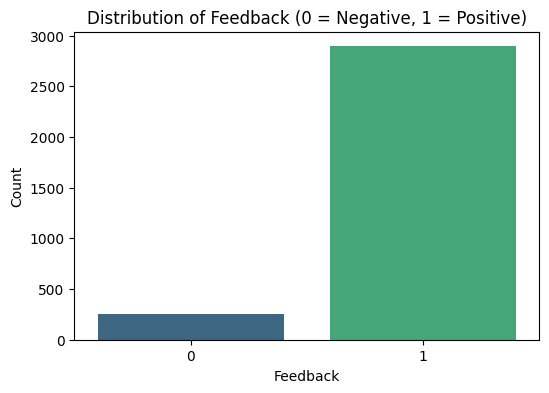

In [3]:
# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

plt.figure(figsize=(6,4))
sns.countplot(x='feedback', data=df, palette='viridis')
plt.title('Distribution of Feedback (0 = Negative, 1 = Positive)')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

/tmp/ipython-input-439626320.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='variation', y='rating', data=df, errorbar=None, palette='coolwarm')


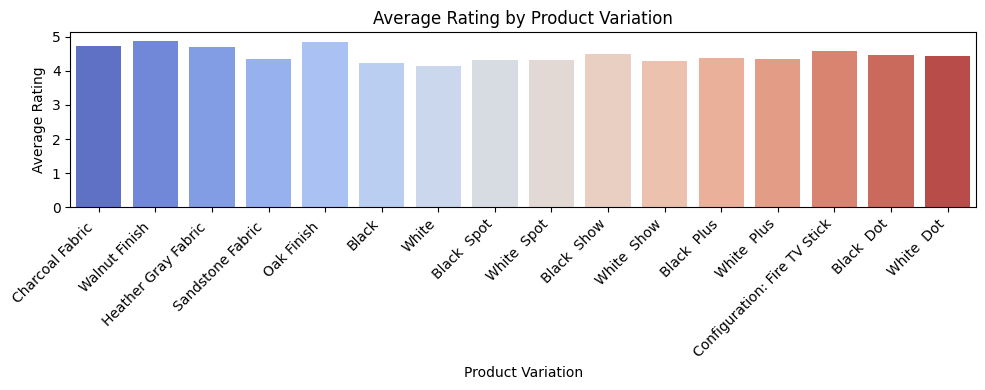

In [4]:
# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

plt.figure(figsize=(10,4))
sns.barplot(x='variation', y='rating', data=df, errorbar=None, palette='coolwarm')
plt.title('Average Rating by Product Variation')
plt.xlabel('Product Variation')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

df = df.drop(['date', 'rating'], axis=1)

# Display confirmation and check remaining columns
print("Columns remaining after dropping 'date' and 'rating':")
print(df.columns.tolist())

Columns remaining after dropping 'date' and 'rating':
['variation', 'verified_reviews', 'feedback']


In [6]:
# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function
# Convert the 'variation' column into multiple binary (0/1) columns
df_encoded = pd.get_dummies(df, columns=['variation'], drop_first=True)

# Display shape and sample of the encoded DataFrame
print("✅ One-hot encoding complete!")
print("New DataFrame shape:", df_encoded.shape)
df_encoded.head()

✅ One-hot encoding complete!
New DataFrame shape: (3150, 17)


,verified_reviews,feedback,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,variation_Sandstone Fabric,variation_Walnut Finish,variation_White,variation_White Dot,variation_White Plus,variation_White Show,variation_White Spot
0,Love my Echo!,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,Loved it!,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,"Sometimes while playing a game, you can answer...",1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,I have had a lot of fun with this thing. My 4 ...,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,Music,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [8]:
# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

from sklearn.feature_extraction.text import CountVectorizer

# Replace missing text with empty strings
df_encoded['verified_reviews'] = df_encoded['verified_reviews'].fillna('')

# Turn the reviews into numbers
cv = CountVectorizer(stop_words='english')
X_text = cv.fit_transform(df_encoded['verified_reviews'])

print("Tokenization done.")
print("Rows and columns:", X_text.shape)

Tokenization done.
Rows and columns: (3150, 3784)


In [9]:
# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes

# Turn the tokenized text into a DataFrame
X_text_df = pd.DataFrame(X_text.toarray(), columns=cv.get_feature_names_out())

# Combine the tokenized words with the rest of the data
X_other = df_encoded.drop(['verified_reviews', 'feedback'], axis=1).reset_index(drop=True)
X_all = pd.concat([X_text_df, X_other], axis=1)

# Set target variable
y = df_encoded['feedback']

print("Data combined. Shape:", X_all.shape)

Data combined. Shape: (3150, 3799)


In [10]:
# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

X = X_all     # all features
y = y          # target variable

print("Data ready for training.")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Data ready for training.
Features shape: (3150, 3799)
Target shape: (3150,)


In [11]:
# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2520, 3799)
Testing data: (630, 3799)


In [12]:
# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


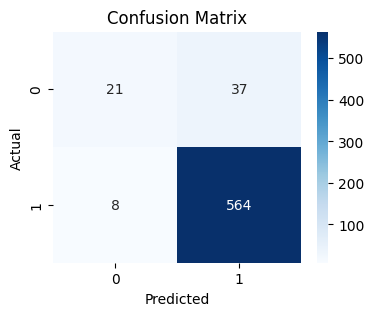

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.36      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.83      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



In [13]:
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test data
y_pred = rf.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

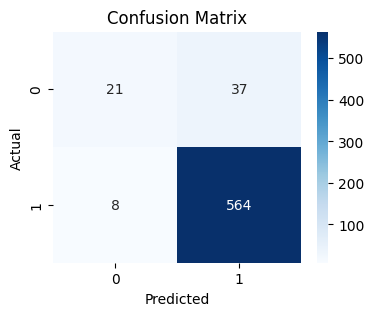

In [14]:
# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

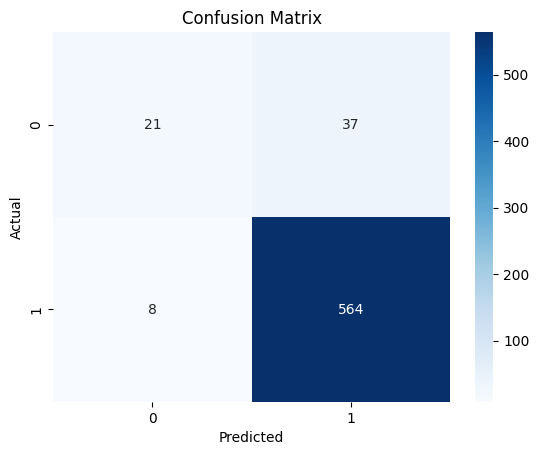

In [15]:
# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:
# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics
from sklearn.metrics import classification_report

# Print out precision, recall, f1-score, and accuracy
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.36      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.83      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



/tmp/ipython-input-343332537.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


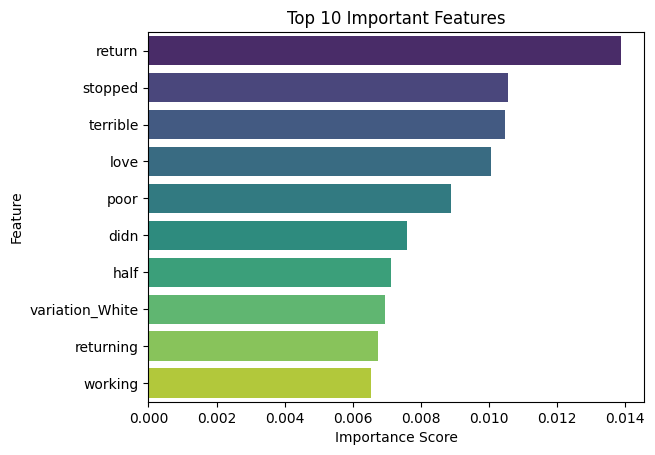

In [17]:
# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get feature importance scores from the trained model
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)

# Show the top 10 most important features
top_features = feat_imp.sort_values(ascending=False).head(10)

# Plot them
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [22]:
# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

def predict_sentiment(review):
    review_vector = cv.transform([review])

    review_df = pd.DataFrame(review_vector.toarray(), columns=cv.get_feature_names_out())

    for col in X_other.columns:
        review_df[col] = 0

    review_df = review_df[X_all.columns]

    result = rf.predict(review_df)[0]

    return "Positive" if result == 1 else "Negative"